# Cognitive Load — Exploratory Data Analysis

**Goal:** Characterise all physiological recordings before feature engineering.

| Item | Detail |
|---|---|
| Cohorts | Pilot (subjects 0–10, single session) · Survey (subjects 11–24 pre/post, subject 19 missing) |
| Signals | BVP (~64 Hz) · EDA (~4 Hz) · Temp (~4 Hz) · EEG band power (~256 Hz) |
| Labels  | `cognitive_load/` → cl = 1 · `baseline/` → cl = 0 |

**Sections:** Class balance · Recording lengths · Sampling rates · Missing data · Sensor artifacts · Subject differences · Stroop label quality · Time alignment


In [59]:
import os
import warnings
import itertools
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from IPython.display import display

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 10,
})

# ── Locate repo root (works whether Jupyter launched from repo root or notebooks/)
_cwd = Path(os.getcwd())
DATA_ROOT = (_cwd.parent if _cwd.name == "notebooks" else _cwd) / "raw_data"
PILOT_DIR  = DATA_ROOT / "pilot"
SURVEY_DIR = DATA_ROOT / "survey_gamification"

CONDITIONS   = {"cognitive_load": 1, "baseline": 0}
SIGNAL_FILES = ["empatica_bvp.csv", "empatica_eda.csv", "empatica_temp.csv", "muse_eeg.csv"]

MODALITY_MAP = {
    "BVP":  "empatica_bvp.csv",
    "EDA":  "empatica_eda.csv",
    "Temp": "empatica_temp.csv",
    "EEG":  "muse_eeg.csv",
}
FNAME_SHORT = {v: k for k, v in MODALITY_MAP.items()}

# Colours shared across all plots
COND_COLORS   = {"cognitive_load": "#EE854A", "baseline": "#4878D0"}
COHORT_COLORS = {"pilot": "#4878D0", "survey": "#EE854A"}
MOD_COLORS    = {"BVP": "#4878D0", "EDA": "#EE854A", "Temp": "#59A14F", "EEG": "#B07AA1"}

PILOT_SUBJECTS  = sorted(
    int(p.name) for p in PILOT_DIR.iterdir() if p.is_dir() and p.name.isdigit()
)
SURVEY_SUBJECTS = sorted(
    int(p.name) for p in SURVEY_DIR.iterdir() if p.is_dir() and p.name.isdigit()
)
ALL_SUBJECTS = PILOT_SUBJECTS + SURVEY_SUBJECTS

print(f"Pilot subjects  : {PILOT_SUBJECTS}")
print(f"Survey subjects : {SURVEY_SUBJECTS}")
print(f"DATA_ROOT       : {DATA_ROOT}")


Pilot subjects  : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Survey subjects : [11, 12, 13, 14, 15, 16, 17, 18, 20, 21, 22, 23, 24]
DATA_ROOT       : /Users/khldnsser/Projects/EECE 503N/Cognitive Load/raw_data


In [60]:
def get_condition_paths(subject_id):
    """Return list of dicts {subject, cohort, session, condition, label, path}."""
    records = []
    if subject_id in PILOT_SUBJECTS:
        base = PILOT_DIR / str(subject_id)
        for cond, label in CONDITIONS.items():
            records.append({
                "subject": subject_id, "cohort": "pilot",
                "session": None, "condition": cond, "label": label,
                "path": base / cond,
            })
    else:
        base = SURVEY_DIR / str(subject_id)
        if not base.exists():
            return []
        for sess in ["pre", "post"]:
            sess_dir = base / sess
            if not sess_dir.exists():
                continue
            for cond, label in CONDITIONS.items():
                records.append({
                    "subject": subject_id, "cohort": "survey",
                    "session": sess, "condition": cond, "label": label,
                    "path": sess_dir / cond,
                })
    return records


def safe_read(path, fname):
    fp = path / fname
    # Subject 3 cognitive_load has a typo: empatica_emda.csv instead of empatica_eda.csv
    if not fp.exists() and fname == "empatica_eda.csv":
        fp = path / "empatica_emda.csv"
    if not fp.exists():
        return None
    df = pd.read_csv(fp)
    if "emda" in df.columns:
        df = df.rename(columns={"emda": "eda"})
    return df


def obs_hz(df, time_col="time"):
    """Observed sampling rate; deduplicates timestamps (handles EEG duplicate rows)."""
    if df is None or len(df) < 2:
        return np.nan
    t = df[time_col].drop_duplicates().sort_values()
    diffs = t.diff().dropna()
    diffs = diffs[diffs > 0]
    if len(diffs) == 0:
        return np.nan
    return round(1.0 / float(diffs.median()), 1)


def duration_s(df, time_col="time"):
    if df is None or len(df) < 2:
        return np.nan
    return float(df[time_col].max() - df[time_col].min())


def max_flatline(series):
    """Length of longest consecutive identical-value run."""
    arr = series.dropna().values
    if len(arr) == 0:
        return 0
    return max(sum(1 for _ in g) for _, g in itertools.groupby(arr))


def dropout_count(df, time_col="time", factor=2.0):
    """Count gaps > factor * median interval (signal dropout events)."""
    if df is None or len(df) < 2:
        return 0, np.nan
    t = df[time_col].drop_duplicates().sort_values()
    diffs = t.diff().dropna()
    diffs = diffs[diffs > 0]
    if len(diffs) == 0:
        return 0, np.nan
    median_dt = float(diffs.median())
    gaps = diffs[diffs > factor * median_dt]
    return int(len(gaps)), float(gaps.max()) if len(gaps) > 0 else np.nan


print("Helper functions defined.")


Helper functions defined.


In [61]:
registry_rows = []
for sid in ALL_SUBJECTS:
    for rec in get_condition_paths(sid):
        row = {k: v for k, v in rec.items() if k != "path"}
        row["path"] = str(rec["path"])
        for fname in SIGNAL_FILES:
            fp = rec["path"] / fname
            # Handle empatica_emda.csv typo (subject 3 cognitive_load)
            if not fp.exists() and fname == "empatica_eda.csv":
                fp = rec["path"] / "empatica_emda.csv"
            row[fname + "_exists"] = fp.exists()
        registry_rows.append(row)

registry = pd.DataFrame(registry_rows)
sig_exist_cols = [f + "_exists" for f in SIGNAL_FILES]

print(f"Total condition-recordings : {len(registry)}")
print(f"  pilot                    : {(registry.cohort == 'pilot').sum()}")
print(f"  survey                   : {(registry.cohort == 'survey').sum()}")
print(f"  cl=0 (baseline)          : {(registry.label == 0).sum()}")
print(f"  cl=1 (cognitive_load)    : {(registry.label == 1).sum()}")
print(f"  all 4 signals present    : {registry[sig_exist_cols].all(axis=1).sum()}")
display(registry.head(8))


Total condition-recordings : 70
  pilot                    : 22
  survey                   : 48
  cl=0 (baseline)          : 35
  cl=1 (cognitive_load)    : 35
  all 4 signals present    : 63


,subject,cohort,session,condition,label,path,empatica_bvp.csv_exists,empatica_eda.csv_exists,empatica_temp.csv_exists,muse_eeg.csv_exists
0,0,pilot,None,cognitive_load,1,/Users/khldnsser/Projects/EECE 503N/Cognitive ...,True,True,True,True
1,0,pilot,None,baseline,0,/Users/khldnsser/Projects/EECE 503N/Cognitive ...,True,True,True,True
2,1,pilot,None,cognitive_load,1,/Users/khldnsser/Projects/EECE 503N/Cognitive ...,True,True,True,True
3,1,pilot,None,baseline,0,/Users/khldnsser/Projects/EECE 503N/Cognitive ...,True,True,True,True
4,2,pilot,None,cognitive_load,1,/Users/khldnsser/Projects/EECE 503N/Cognitive ...,True,True,True,True
5,2,pilot,None,baseline,0,/Users/khldnsser/Projects/EECE 503N/Cognitive ...,True,True,True,True
6,3,pilot,None,cognitive_load,1,/Users/khldnsser/Projects/EECE 503N/Cognitive ...,True,True,True,False
7,3,pilot,None,baseline,0,/Users/khldnsser/Projects/EECE 503N/Cognitive ...,True,True,True,False


## 1. Class Balance

How many condition-recordings exist per label, per cohort, and per subject?


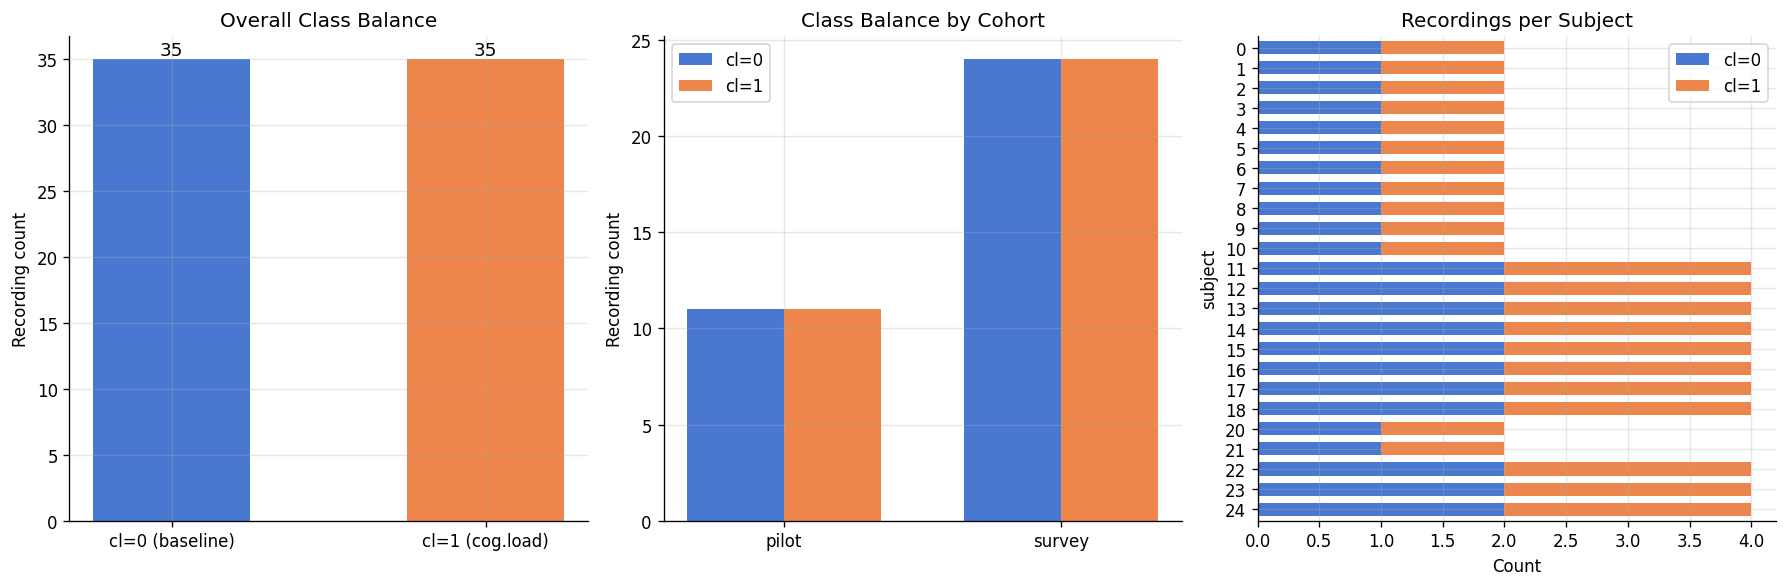


Recordings per subject:


,cl=0,cl=1
subject,,
0,1,1
1,1,1
2,1,1
3,1,1
4,1,1
5,1,1
6,1,1
7,1,1
8,1,1


In [62]:
valid = registry[registry[sig_exist_cols].any(axis=1)].copy()

label_counts   = valid.groupby("label").size()
label_counts.index = ["cl=0 (baseline)", "cl=1 (cog.load)"]
cohort_counts  = valid.groupby(["cohort", "label"]).size().unstack(fill_value=0)
cohort_counts.columns = ["cl=0", "cl=1"]
subject_counts = valid.groupby(["subject", "label"]).size().unstack(fill_value=0)
subject_counts.columns = ["cl=0", "cl=1"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Panel 1: overall
bars = axes[0].bar(label_counts.index, label_counts.values,
                   color=["#4878D0", "#EE854A"], width=0.5)
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.3, str(int(bar.get_height())),
                 ha="center", fontsize=11)
axes[0].set_title("Overall Class Balance")
axes[0].set_ylabel("Recording count")

# Panel 2: by cohort
x = np.arange(len(cohort_counts))
w = 0.35
for j, (col, clr) in enumerate(zip(["cl=0", "cl=1"], ["#4878D0", "#EE854A"])):
    axes[1].bar(x + j * w - w / 2, cohort_counts[col], width=w, color=clr, label=col)
axes[1].set_xticks(x)
axes[1].set_xticklabels(cohort_counts.index)
axes[1].set_title("Class Balance by Cohort")
axes[1].legend()
axes[1].set_ylabel("Recording count")

# Panel 3: per-subject stacked horizontal
subject_counts.plot(kind="barh", stacked=True, ax=axes[2],
                    color=["#4878D0", "#EE854A"], width=0.65)
axes[2].set_title("Recordings per Subject")
axes[2].set_xlabel("Count")
axes[2].legend(["cl=0", "cl=1"])
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

print("\nRecordings per subject:")
display(subject_counts)


## 2. Recording Lengths

Duration in seconds, computed from the BVP timestamp span (min → max Unix timestamp).

> **Note:** `cognitive_load` recordings are typically ~2× longer than `baseline` recordings,
> creating a *time imbalance* even though recording counts are balanced 1:1.


Duration (seconds) by cohort & condition:


count   mean   std    min    25%    50%    75%    max
cohort condition                                                            
pilot  baseline         11.0  148.3  37.8   92.8  121.0  124.6  182.0  202.2
       cognitive_load   11.0  257.0  48.6  129.0  244.9  267.8  282.3  306.8
survey baseline         24.0  190.3  17.0  182.7  183.7  184.1  186.4  264.4
       cognitive_load   24.0  282.5  66.6   32.4  264.0  285.5  302.7  430.0

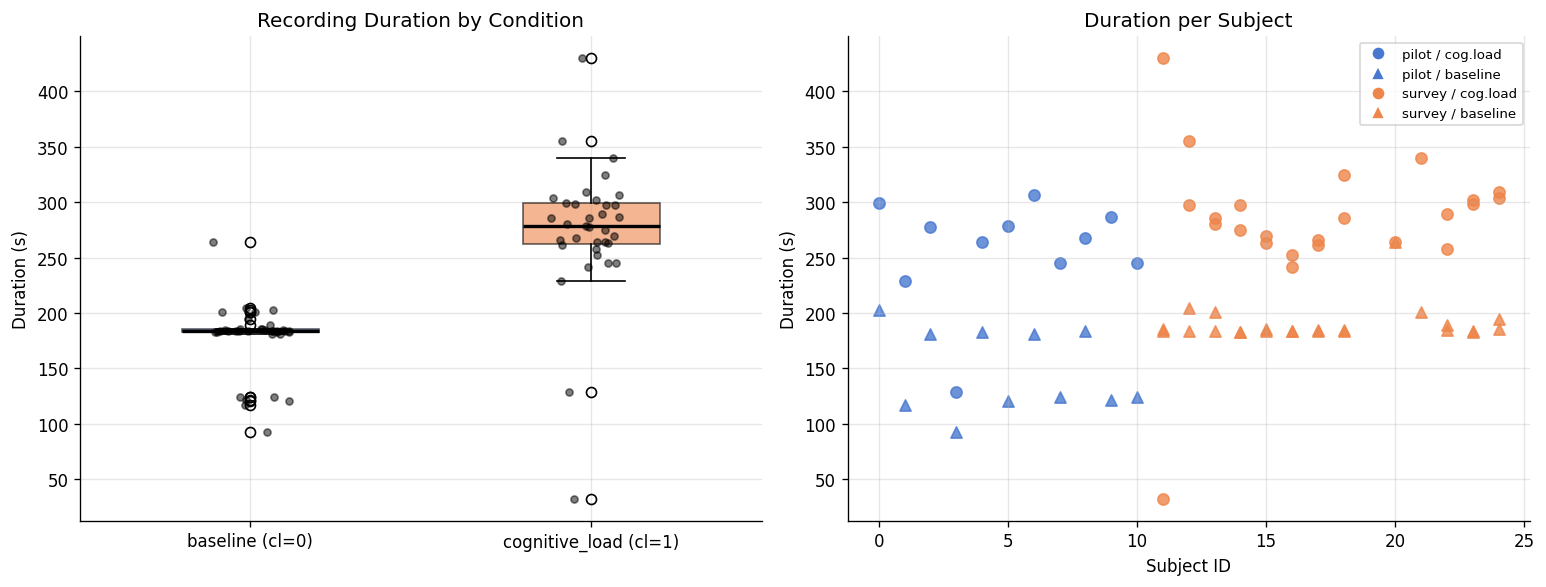

In [63]:
durations = []
for _, row in registry.iterrows():
    path = Path(row["path"])
    df   = safe_read(path, "empatica_bvp.csv")
    durations.append({
        "subject": row["subject"], "cohort": row["cohort"],
        "session": row["session"], "condition": row["condition"],
        "label": row["label"], "duration_s": duration_s(df),
    })
dur_df = pd.DataFrame(durations)

print("Duration (seconds) by cohort & condition:")
display(dur_df.groupby(["cohort", "condition"])["duration_s"].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cond_list = ["baseline", "cognitive_load"]

# Panel 1: box + jitter
bp_data = [dur_df[dur_df["condition"] == c]["duration_s"].dropna().values for c in cond_list]
bp = axes[0].boxplot(bp_data, positions=[0, 1], widths=0.4, patch_artist=True,
                     medianprops={"color": "black", "linewidth": 2})
for patch, clr in zip(bp["boxes"], ["#4878D0", "#EE854A"]):
    patch.set_facecolor(clr)
    patch.set_alpha(0.6)
rng = np.random.default_rng(42)
for i, data in enumerate(bp_data):
    jit = rng.uniform(-0.12, 0.12, len(data))
    axes[0].scatter(np.full(len(data), i) + jit, data, s=18, color="black", alpha=0.5, zorder=3)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["baseline (cl=0)", "cognitive_load (cl=1)"])
axes[0].set_ylabel("Duration (s)")
axes[0].set_title("Recording Duration by Condition")

# Panel 2: per-subject scatter
COND_MARKERS = {"cognitive_load": "o", "baseline": "^"}
for _, r in dur_df.iterrows():
    if np.isnan(r["duration_s"]):
        continue
    axes[1].scatter(r["subject"], r["duration_s"],
                    c=COHORT_COLORS[r["cohort"]], marker=COND_MARKERS[r["condition"]],
                    s=45, alpha=0.8)
legend_els = [
    Line2D([0],[0], marker="o", color="w", markerfacecolor="#4878D0", markersize=8, label="pilot / cog.load"),
    Line2D([0],[0], marker="^", color="w", markerfacecolor="#4878D0", markersize=8, label="pilot / baseline"),
    Line2D([0],[0], marker="o", color="w", markerfacecolor="#EE854A", markersize=8, label="survey / cog.load"),
    Line2D([0],[0], marker="^", color="w", markerfacecolor="#EE854A", markersize=8, label="survey / baseline"),
]
axes[1].legend(handles=legend_els, fontsize=8)
axes[1].set_xlabel("Subject ID")
axes[1].set_ylabel("Duration (s)")
axes[1].set_title("Duration per Subject")

plt.tight_layout()
plt.show()


## 3. Observed Sampling Rates

Nominal: BVP ≈ 64 Hz · EDA ≈ 4 Hz · Temp ≈ 4 Hz · EEG ≈ 256 Hz

> **EEG note:** The Muse SDK writes 2–5 duplicate rows per millisecond timestamp (windowed FFT output).
> `obs_hz()` deduplicates timestamps before computing the median interval.
> Without deduplication the result would be ~1 000 Hz (the raw file write rate).


Sampling rate summary (Hz):


,BVP_hz,EDA_hz,Temp_hz,EEG_hz
count,70.0,70.0,70.0,63.0
mean,64.0,4.0,4.0,1000.1
std,0.0,0.0,0.0,0.0
min,64.0,4.0,4.0,1000.1
25%,64.0,4.0,4.0,1000.1
50%,64.0,4.0,4.0,1000.1
75%,64.0,4.0,4.0,1000.1
max,64.0,4.0,4.0,1000.1


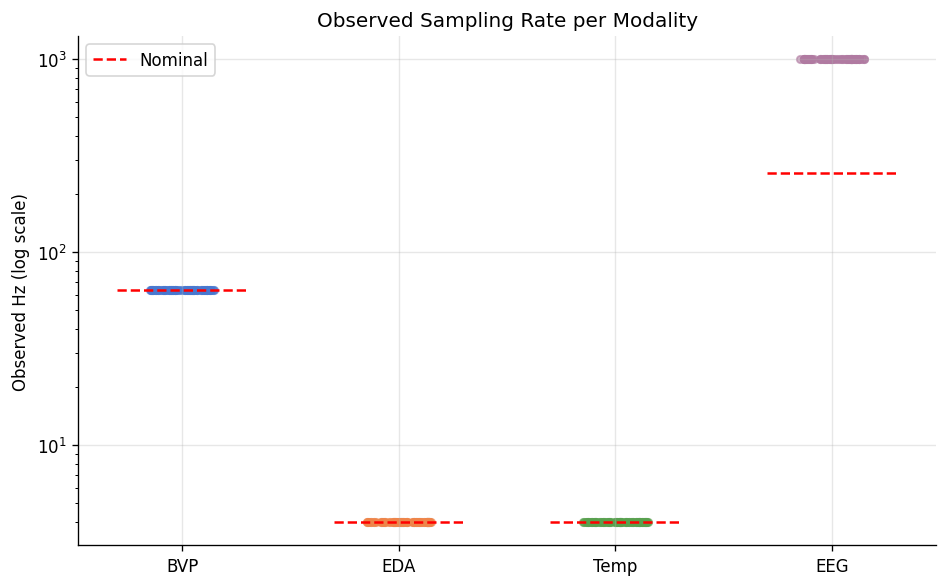

In [64]:
hz_rows = []
for _, rec in registry.iterrows():
    path = Path(rec["path"])
    row  = {"subject": rec["subject"], "cohort": rec["cohort"], "condition": rec["condition"]}
    for mod, fname in MODALITY_MAP.items():
        df = safe_read(path, fname)
        row[f"{mod}_hz"] = obs_hz(df)
    hz_rows.append(row)
hz_df = pd.DataFrame(hz_rows)

print("Sampling rate summary (Hz):")
display(hz_df[["BVP_hz", "EDA_hz", "Temp_hz", "EEG_hz"]].describe().round(2))

# Strip plot (log scale)
fig, ax = plt.subplots(figsize=(8, 5))
mods    = list(MODALITY_MAP.keys())
nominal = {"BVP": 64, "EDA": 4, "Temp": 4, "EEG": 256}
rng     = np.random.default_rng(0)
for i, mod in enumerate(mods):
    vals = hz_df[f"{mod}_hz"].dropna().values
    jit  = rng.uniform(-0.15, 0.15, len(vals))
    ax.scatter(np.full(len(vals), i) + jit, vals, s=20, alpha=0.6, color=MOD_COLORS[mod])
    ax.plot([i - 0.3, i + 0.3], [nominal[mod], nominal[mod]], "r--", linewidth=1.5,
            label="Nominal" if i == 0 else "")
ax.set_xticks(range(len(mods)))
ax.set_xticklabels(mods)
ax.set_yscale("log")
ax.set_ylabel("Observed Hz (log scale)")
ax.set_title("Observed Sampling Rate per Modality")
ax.legend()
plt.tight_layout()
plt.show()


## 4. Missing Data

**4a.** Which signal files are absent for which recordings?
**4b.** How many NaN values exist within files that are present?


Recordings with ≥1 missing signal file: 7


,subject,cohort,session,condition,BVP,EDA,Temp,EEG
6,3,pilot,None,cognitive_load,True,True,True,False
7,3,pilot,None,baseline,True,True,True,False
22,11,survey,pre,cognitive_load,True,True,True,False
36,14,survey,post,cognitive_load,True,True,True,False
37,14,survey,post,baseline,True,True,True,False
55,20,survey,pre,baseline,True,True,True,False
66,24,survey,pre,cognitive_load,True,True,True,False


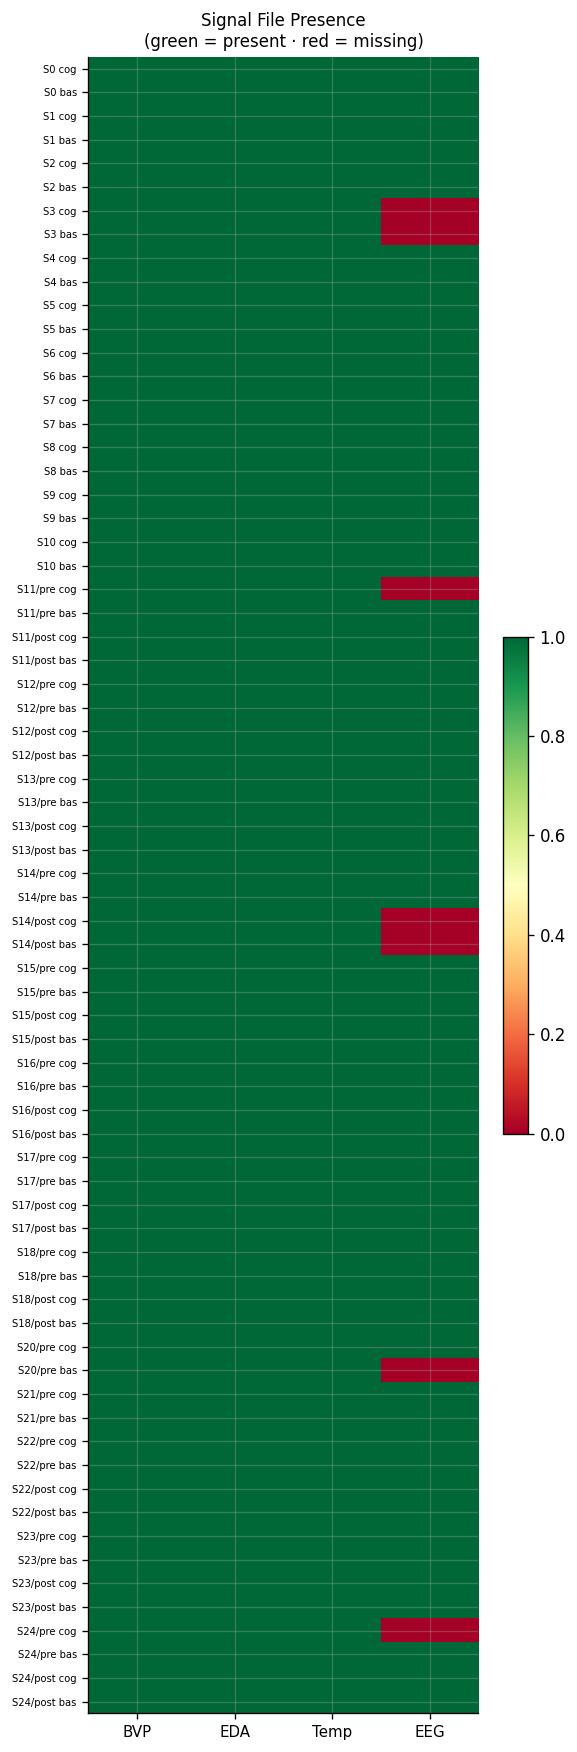

In [65]:
presence_cols = [f + "_exists" for f in SIGNAL_FILES]

def row_label(r):
    sess = f"/{r['session']}" if r["session"] else ""
    return f"S{r['subject']}{sess} {r['condition'][:3]}"

labels_y = [row_label(r) for _, r in registry.iterrows()]
matrix   = registry[presence_cols].values.astype(int)
missing  = ~registry[presence_cols].all(axis=1)

print(f"Recordings with ≥1 missing signal file: {missing.sum()}")
if missing.any():
    show = registry[missing][["subject", "cohort", "session", "condition"] + presence_cols].copy()
    show.columns = ["subject", "cohort", "session", "condition"] + list(FNAME_SHORT.values())
    display(show)

fig, ax = plt.subplots(figsize=(5, max(8, len(labels_y) * 0.21)))
im = ax.imshow(matrix, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1, interpolation="none")
ax.set_xticks(range(4))
ax.set_xticklabels(list(FNAME_SHORT.values()), fontsize=9)
ax.set_yticks(range(len(labels_y)))
ax.set_yticklabels(labels_y, fontsize=6)
ax.set_title("Signal File Presence\n(green = present · red = missing)", fontsize=10)
plt.colorbar(im, ax=ax, shrink=0.3)
plt.tight_layout()
plt.show()


NaN % by modality:


nan_count                                                         \
             count      mean       std     min      25%      50%      75%   
modality                                                                    
BVP           70.0      0.00      0.00     0.0      0.0      0.0      0.0   
EDA           70.0      0.00      0.00     0.0      0.0      0.0      0.0   
EEG           63.0  59366.54  17039.89  8768.0  48384.0  52948.0  75075.0   
Temp          70.0      0.00      0.00     0.0      0.0      0.0      0.0   

                  nan_pct                                            
              max   count  mean   std   min   25%   50%   75%   max  
modality                                                             
BVP           0.0    70.0  0.00  0.00  0.00  0.00  0.00  0.00  0.00  
EDA           0.0    70.0  0.00  0.00  0.00  0.00  0.00  0.00  0.00  
EEG       90922.0    63.0  2.64  0.08  2.51  2.57  2.63  2.69  2.84  
Temp          0.0    70.0  0.00  0.00  0.00  0.00  0.00  0.00  0.00

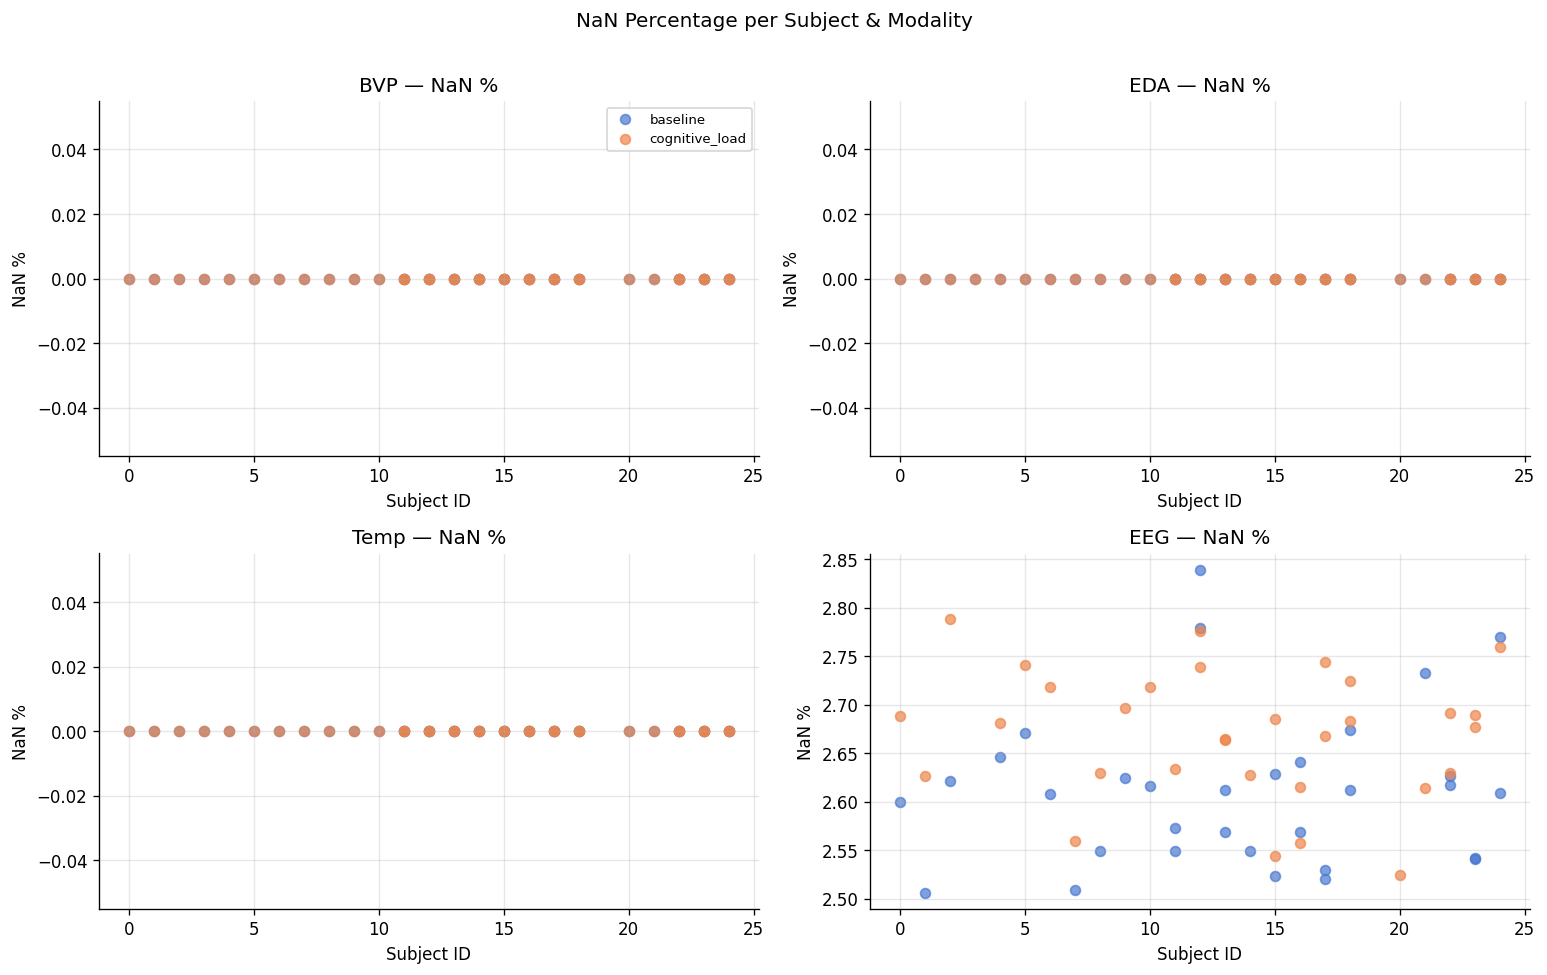

In [66]:
nan_rows = []
for _, rec in registry.iterrows():
    path = Path(rec["path"])
    for fname in SIGNAL_FILES:
        df = safe_read(path, fname)
        if df is None:
            continue
        nan_n = int(df.isnull().sum().sum())
        total = df.shape[0] * df.shape[1]
        nan_rows.append({
            "subject":   rec["subject"],
            "cohort":    rec["cohort"],
            "condition": rec["condition"],
            "modality":  FNAME_SHORT[fname],
            "nan_count": nan_n,
            "nan_pct":   100.0 * nan_n / total if total > 0 else np.nan,
        })
nan_df = pd.DataFrame(nan_rows)

print("NaN % by modality:")
display(nan_df.groupby("modality")[["nan_count", "nan_pct"]].describe().round(2))

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()
for i, mod in enumerate(["BVP", "EDA", "Temp", "EEG"]):
    sub = nan_df[nan_df["modality"] == mod]
    for cond, grp in sub.groupby("condition"):
        axes[i].scatter(grp["subject"], grp["nan_pct"],
                        label=cond, alpha=0.7, s=35, color=COND_COLORS.get(cond, "gray"))
    axes[i].set_title(f"{mod} — NaN %")
    axes[i].set_xlabel("Subject ID")
    axes[i].set_ylabel("NaN %")
    if i == 0:
        axes[i].legend(fontsize=8)
plt.suptitle("NaN Percentage per Subject & Modality", y=1.01)
plt.tight_layout()
plt.show()


## 5. Sensor Artifacts

Three artifact types:
1. **Flatlines** — runs of identical consecutive values (device saturation or disconnection)
2. **Signal dropout** — timestamp gaps > 2 × median interval (BLE packet loss)
3. **EEG headband quality** — HSI indicator (1.0 = good contact) and `HeadBandOn` flag


Recordings exceeding flatline threshold: 3


,subject,cohort,condition,modality,max_flatline,threshold,exceeds
197,18,survey,cognitive_load,Temp,76,60,True
268,24,survey,cognitive_load,EEG,70,50,True
155,15,survey,cognitive_load,BVP,11,10,True


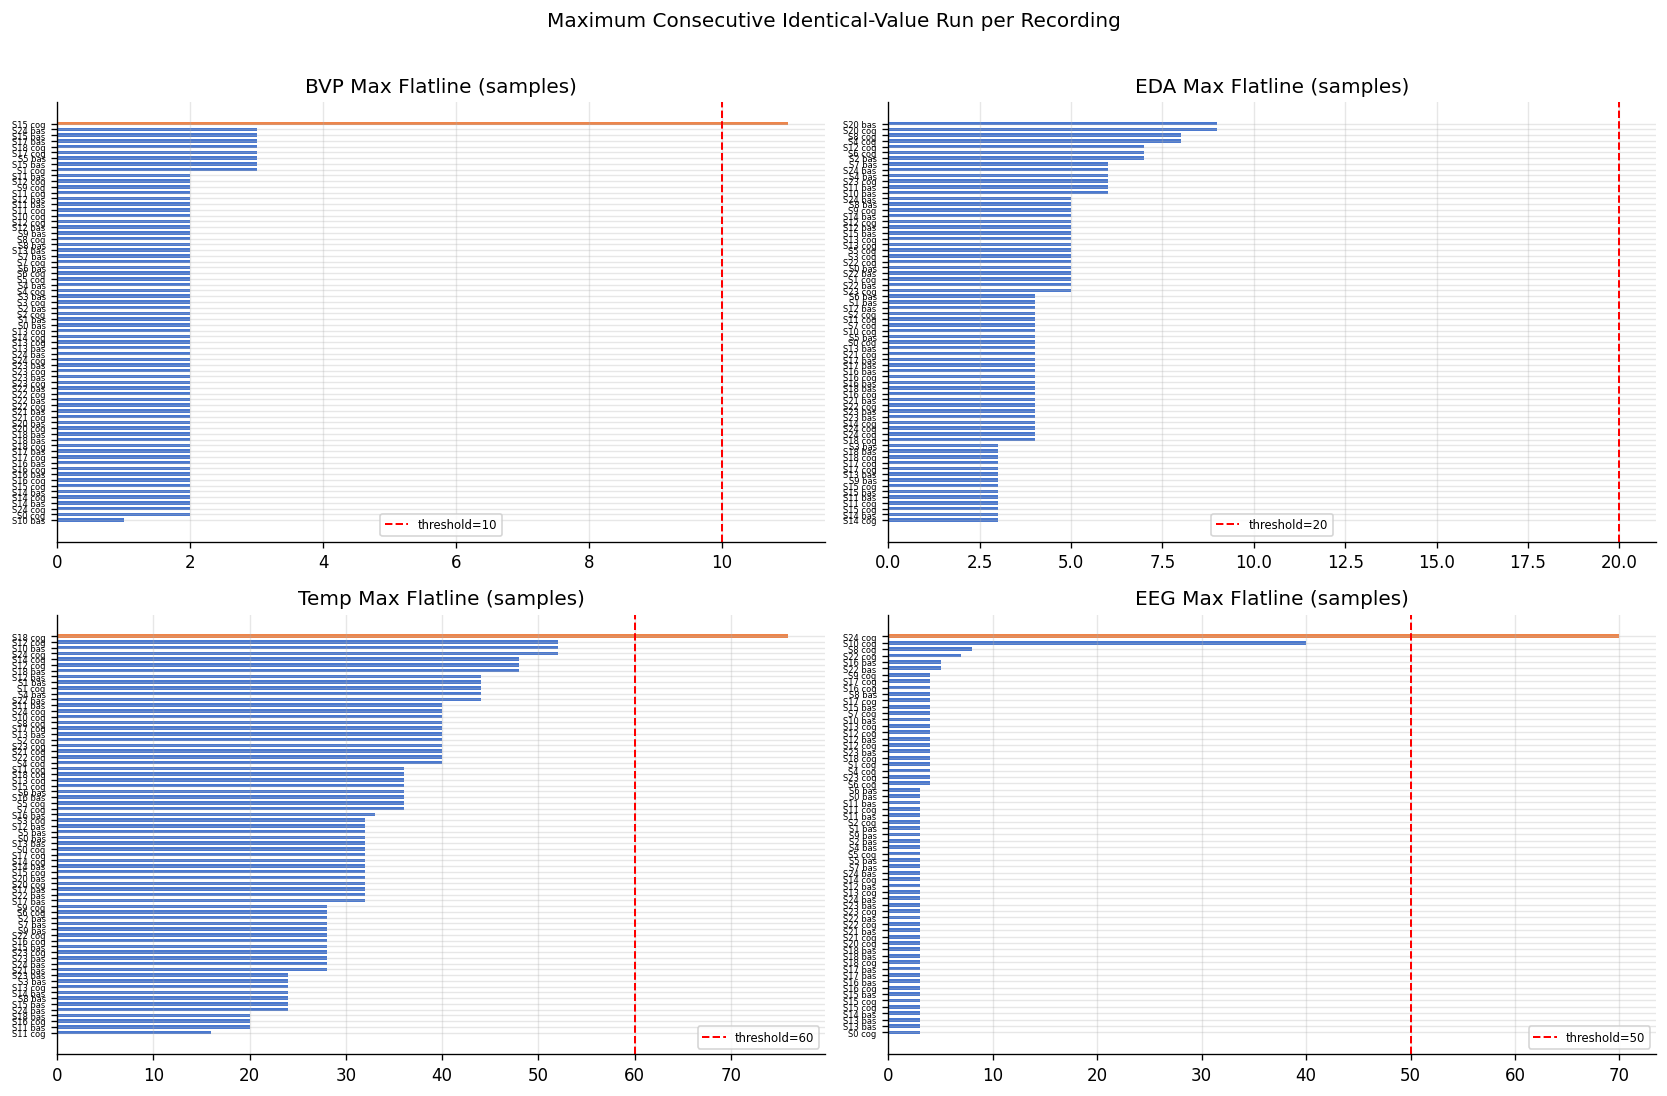

In [67]:
# (column, flatline threshold in samples)
FILE_COL_THRESH = {
    "empatica_bvp.csv":  ("bvp",     10),   # >10 @ 64 Hz  = >156 ms
    "empatica_eda.csv":  ("eda",     20),   # >20 @ 4 Hz   = >5 s
    "empatica_temp.csv": ("temp",    60),   # >60 @ 4 Hz   = >15 s
    "muse_eeg.csv":      ("RAW_TP9", 50),   # >50 @ ~256 Hz = >195 ms
}

fl_rows = []
for _, rec in registry.iterrows():
    path = Path(rec["path"])
    for fname, (col, thresh) in FILE_COL_THRESH.items():
        df = safe_read(path, fname)
        if df is None or col not in df.columns:
            continue
        fl = max_flatline(df[col])
        fl_rows.append({
            "subject": rec["subject"], "cohort": rec["cohort"],
            "condition": rec["condition"],
            "modality": FNAME_SHORT[fname],
            "max_flatline": fl, "threshold": thresh,
            "exceeds": fl > thresh,
        })
fl_df = pd.DataFrame(fl_rows)

flagged = fl_df[fl_df["exceeds"]].sort_values("max_flatline", ascending=False)
print(f"Recordings exceeding flatline threshold: {len(flagged)}")
if not flagged.empty:
    display(flagged.head(20))

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()
mod_thresh = {"BVP": 10, "EDA": 20, "Temp": 60, "EEG": 50}
for i, mod in enumerate(["BVP", "EDA", "Temp", "EEG"]):
    sub = fl_df[fl_df["modality"] == mod].sort_values("max_flatline", ascending=True)
    if sub.empty:
        axes[i].set_visible(False)
        continue
    colors_bar = ["#EE854A" if e else "#4878D0" for e in sub["exceeds"]]
    y_pos = range(len(sub))
    axes[i].barh(list(y_pos), sub["max_flatline"].values, color=colors_bar, height=0.6)
    axes[i].axvline(mod_thresh[mod], color="red", linestyle="--",
                    linewidth=1.2, label=f"threshold={mod_thresh[mod]}")
    axes[i].set_yticks(list(y_pos))
    axes[i].set_yticklabels(
        [f"S{r['subject']} {r['condition'][:3]}" for _, r in sub.iterrows()], fontsize=5)
    axes[i].set_title(f"{mod} Max Flatline (samples)")
    axes[i].legend(fontsize=7)
plt.suptitle("Maximum Consecutive Identical-Value Run per Recording", y=1.01)
plt.tight_layout()
plt.show()


Dropout event summary by modality:


n_gaps                                                           \
          count     mean      std    min     25%     50%     75%     max   
modality                                                                   
BVP        70.0     0.00     0.00    0.0     0.0     0.0     0.0     0.0   
EDA        70.0     0.00     0.00    0.0     0.0     0.0     0.0     0.0   
EEG        63.0  4769.24  1325.66  698.0  3956.0  4101.0  5931.5  7329.0   
Temp       70.0     0.00     0.00    0.0     0.0     0.0     0.0     0.0   

         max_gap_s                                            
             count  mean   std   min   25%   50%   75%   max  
modality                                                      
BVP            0.0   NaN   NaN   NaN   NaN   NaN   NaN   NaN  
EDA            0.0   NaN   NaN   NaN   NaN   NaN   NaN   NaN  
EEG           63.0  1.33  3.14  0.07  0.13  0.15  0.17  9.74  
Temp           0.0   NaN   NaN   NaN   NaN   NaN   NaN   NaN

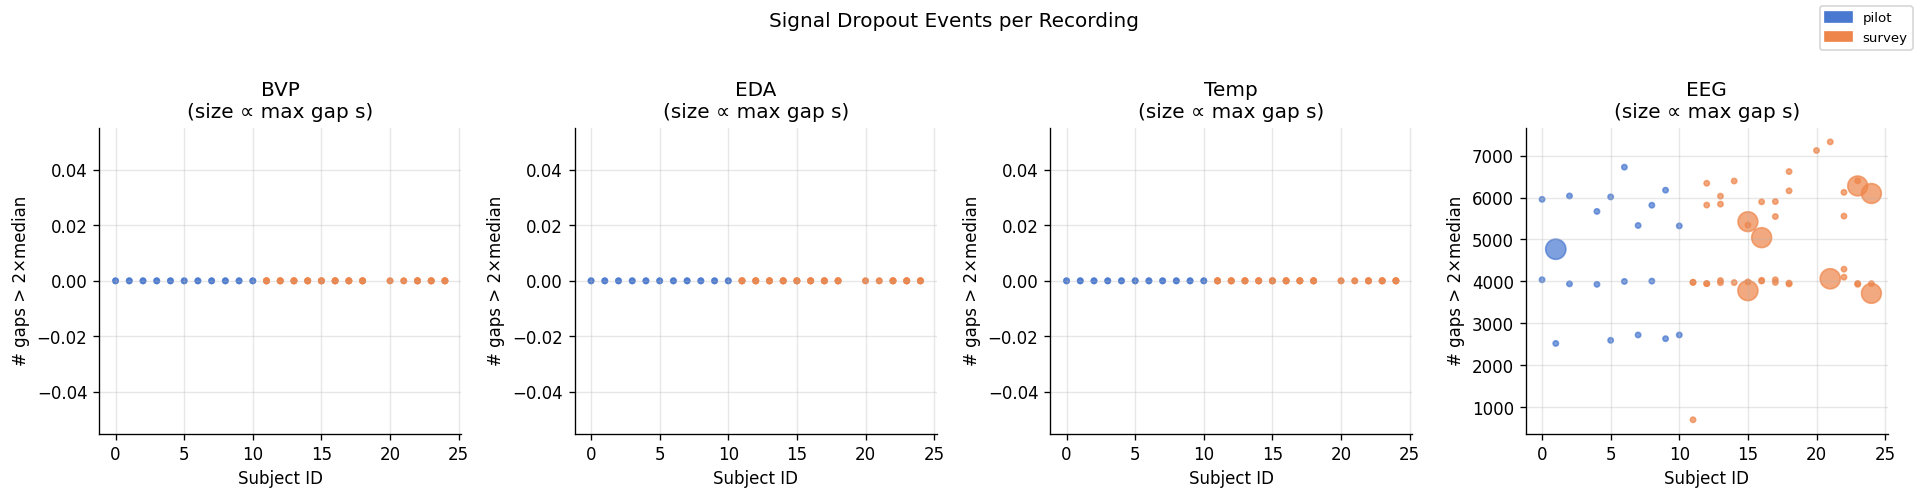

In [68]:
drop_rows = []
for _, rec in registry.iterrows():
    path = Path(rec["path"])
    for fname in SIGNAL_FILES:
        df = safe_read(path, fname)
        if df is None:
            continue
        if fname == "muse_eeg.csv":
            df = df.drop_duplicates("time")
        n_gaps, max_gap = dropout_count(df)
        drop_rows.append({
            "subject": rec["subject"], "cohort": rec["cohort"],
            "condition": rec["condition"],
            "modality": FNAME_SHORT[fname],
            "n_gaps": n_gaps, "max_gap_s": max_gap,
        })
drop_df = pd.DataFrame(drop_rows)

print("Dropout event summary by modality:")
display(drop_df.groupby("modality")[["n_gaps", "max_gap_s"]].describe().round(2))

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, mod in enumerate(["BVP", "EDA", "Temp", "EEG"]):
    sub = drop_df[drop_df["modality"] == mod].dropna(subset=["n_gaps"])
    sizes  = np.clip(sub["max_gap_s"].fillna(0).values * 15, 10, 400)
    colors_sc = [COHORT_COLORS.get(c, "gray") for c in sub["cohort"]]
    axes[i].scatter(sub["subject"], sub["n_gaps"], s=sizes, c=colors_sc, alpha=0.7)
    axes[i].set_title(f"{mod}\n(size ∝ max gap s)")
    axes[i].set_xlabel("Subject ID")
    axes[i].set_ylabel("# gaps > 2×median")
# Legend
legend_els = [mpatches.Patch(color=c, label=k) for k, c in COHORT_COLORS.items()]
fig.legend(handles=legend_els, loc="upper right", fontsize=8)
plt.suptitle("Signal Dropout Events per Recording", y=1.03)
plt.tight_layout()
plt.show()


EEG headband quality summary (%):


,headband_on_pct,mean_hsi_good
count,63.0,63.0
mean,99.7,90.3
std,0.4,10.2
min,98.2,59.0
25%,99.8,86.7
50%,99.9,93.9
75%,99.9,97.9
max,100.0,100.0



Recordings with mean HSI good% < 80: 11


,subject,cohort,condition,headband_on_pct,mean_hsi_good
0,0,pilot,cognitive_load,99.796134,68.194025
4,2,pilot,cognitive_load,99.688106,76.733682
8,5,pilot,cognitive_load,99.739561,79.807612
23,12,survey,cognitive_load,99.742193,76.406039
24,12,survey,baseline,99.698929,75.319623
25,12,survey,cognitive_load,99.701578,71.862984
26,12,survey,baseline,99.633482,67.360861
45,18,survey,cognitive_load,99.757906,58.971983
47,18,survey,cognitive_load,99.801915,62.020328
51,21,survey,baseline,98.728166,76.868522


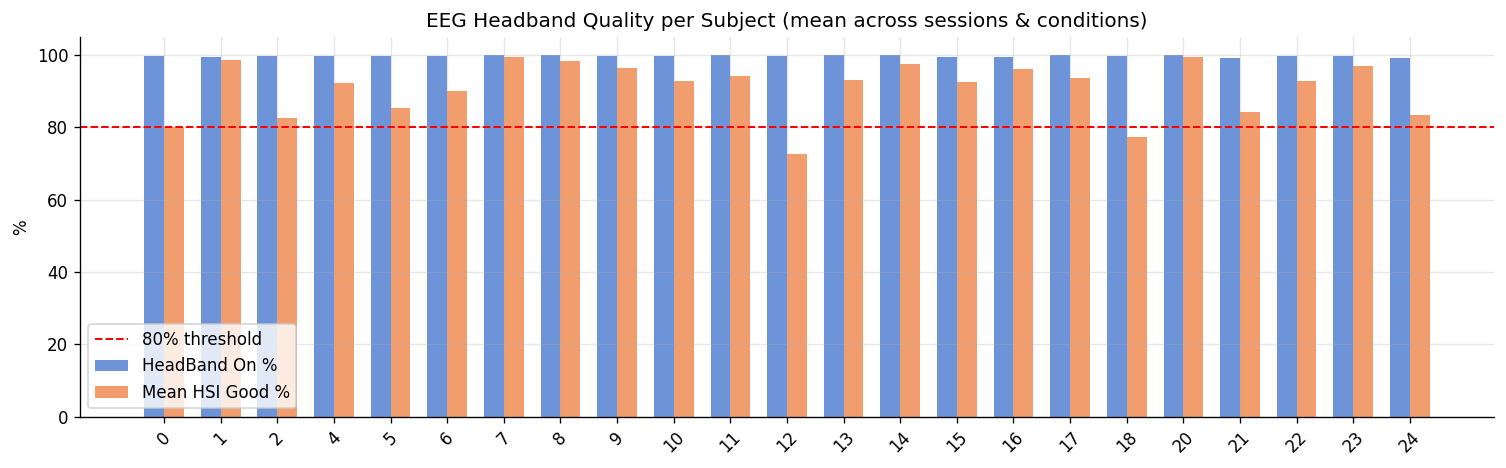

In [69]:
HSI_COLS = ["HSI_TP9", "HSI_AF7", "HSI_AF8", "HSI_TP10"]

hsi_rows = []
for _, rec in registry[registry["muse_eeg.csv_exists"]].iterrows():
    path = Path(rec["path"])
    df   = safe_read(path, "muse_eeg.csv")
    if df is None:
        continue
    row = {"subject": rec["subject"], "cohort": rec["cohort"], "condition": rec["condition"]}
    row["headband_on_pct"] = 100.0 * (df["HeadBandOn"] == 1.0).mean()
    for col in HSI_COLS:
        if col in df.columns:
            row[f"{col}_good"] = 100.0 * (df[col] == 1.0).mean()
    hsi_rows.append(row)
hsi_df = pd.DataFrame(hsi_rows)

good_cols = [c + "_good" for c in HSI_COLS if c + "_good" in hsi_df.columns]
hsi_df["mean_hsi_good"] = hsi_df[good_cols].mean(axis=1)

print("EEG headband quality summary (%):")
display(hsi_df[["headband_on_pct", "mean_hsi_good"]].describe().round(1))

flagged_hsi = hsi_df[hsi_df["mean_hsi_good"] < 80]
if not flagged_hsi.empty:
    print(f"\nRecordings with mean HSI good% < 80: {len(flagged_hsi)}")
    display(flagged_hsi[["subject", "cohort", "condition", "headband_on_pct", "mean_hsi_good"]])

subjects_hsi = sorted(hsi_df["subject"].unique())
fig, ax = plt.subplots(figsize=(max(10, len(subjects_hsi) * 0.55), 4))
x = np.arange(len(subjects_hsi))
w = 0.35
for j, (col, label, clr) in enumerate([
    ("headband_on_pct", "HeadBand On %", "#4878D0"),
    ("mean_hsi_good",   "Mean HSI Good %", "#EE854A"),
]):
    vals = [hsi_df[hsi_df["subject"] == s][col].mean() for s in subjects_hsi]
    ax.bar(x + j * w - w / 2, vals, width=w, label=label, color=clr, alpha=0.8)
ax.axhline(80, color="red", linestyle="--", linewidth=1.2, label="80% threshold")
ax.set_xticks(x)
ax.set_xticklabels(subjects_hsi, rotation=45)
ax.set_ylabel("%")
ax.set_title("EEG Headband Quality per Subject (mean across sessions & conditions)")
ax.legend()
plt.tight_layout()
plt.show()


## 6. Subject-Level Signal Characteristics

How much do physiological signals vary *across* subjects versus *within* subjects?
High inter-subject variability (especially EDA) motivates **per-subject normalisation**
in the feature engineering stage.


Mean signal characteristics by cohort & condition:


eda_mean  bvp_std  temp_mean  eeg_theta_alpha
cohort condition                                                    
pilot  baseline           0.401   45.594     33.344            0.331
       cognitive_load     0.371   55.861     33.715            0.287
survey baseline           0.996   47.920     33.199            0.419
       cognitive_load     0.868   57.442     33.557            0.404

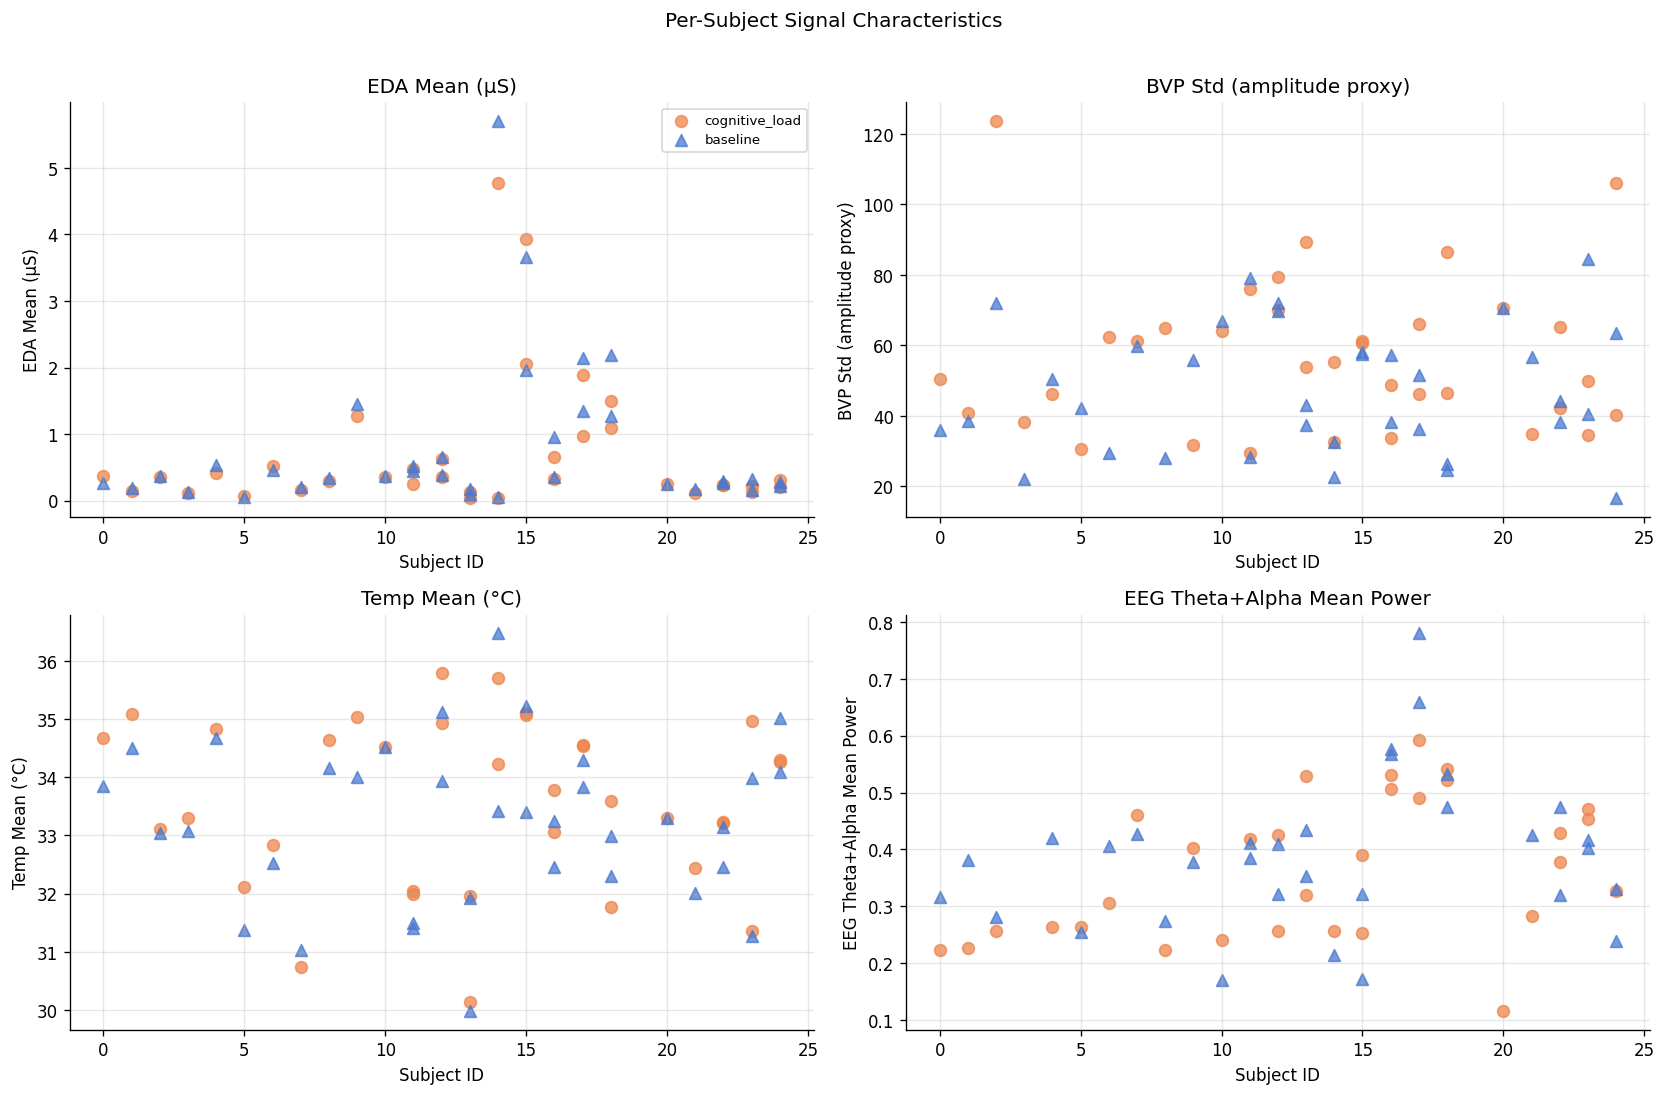

In [70]:
EEG_THETA_ALPHA = ["Theta_TP9","Theta_AF7","Theta_AF8","Theta_TP10",
                   "Alpha_TP9","Alpha_AF7","Alpha_AF8","Alpha_TP10"]

stat_rows = []
for _, rec in registry.iterrows():
    path = Path(rec["path"])
    row  = {"subject": rec["subject"], "cohort": rec["cohort"],
            "condition": rec["condition"], "label": rec["label"]}

    df_eda = safe_read(path, "empatica_eda.csv")
    if df_eda is not None:
        row["eda_mean"] = float(df_eda["eda"].mean())
        row["eda_std"]  = float(df_eda["eda"].std())

    df_bvp = safe_read(path, "empatica_bvp.csv")
    if df_bvp is not None:
        row["bvp_std"] = float(df_bvp["bvp"].std())

    df_tmp = safe_read(path, "empatica_temp.csv")
    if df_tmp is not None:
        row["temp_mean"] = float(df_tmp["temp"].mean())

    df_eeg = safe_read(path, "muse_eeg.csv")
    if df_eeg is not None:
        present = [c for c in EEG_THETA_ALPHA if c in df_eeg.columns]
        if present:
            row["eeg_theta_alpha"] = float(df_eeg[present].mean().mean())

    stat_rows.append(row)
stat_df = pd.DataFrame(stat_rows)

print("Mean signal characteristics by cohort & condition:")
display(stat_df.groupby(["cohort", "condition"])[
    ["eda_mean", "bvp_std", "temp_mean", "eeg_theta_alpha"]
].mean().round(3))

metrics = [
    ("eda_mean",        "EDA Mean (µS)"),
    ("bvp_std",         "BVP Std (amplitude proxy)"),
    ("temp_mean",       "Temp Mean (°C)"),
    ("eeg_theta_alpha", "EEG Theta+Alpha Mean Power"),
]
COND_MARKERS = {"cognitive_load": "o", "baseline": "^"}
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()
for i, (col, title) in enumerate(metrics):
    if col not in stat_df.columns:
        axes[i].set_visible(False)
        continue
    for cond, clr in COND_COLORS.items():
        sub = stat_df[stat_df["condition"] == cond]
        axes[i].scatter(sub["subject"], sub[col], color=clr, label=cond,
                        alpha=0.75, s=50, marker=COND_MARKERS[cond])
    axes[i].set_xlabel("Subject ID")
    axes[i].set_ylabel(title)
    axes[i].set_title(title)
    if i == 0:
        axes[i].legend(fontsize=8)
plt.suptitle("Per-Subject Signal Characteristics", y=1.01)
plt.tight_layout()
plt.show()


## 7. Stroop Task Label Quality

`stroop_responses.csv` is only in `cognitive_load/` folders.
Examining accuracy, response times, and the Stroop **congruency effect**
validates that the cognitive load induction was effective.

Status codes: 1 = correct · 2 = wrong · 3 = timeout


In [71]:
stroop_dfs = []
for _, rec in registry[registry["label"] == 1].iterrows():
    path = Path(rec["path"])
    fp   = path / "stroop_responses.csv"
    if not fp.exists():
        continue
    df = pd.read_csv(fp)
    # Rename awkward column names robustly
    rename_map = {}
    for col in df.columns:
        lc = col.lower()
        if "stroop_color_match" in lc:
            rename_map[col] = "congruent"
        elif lc.startswith("status"):
            rename_map[col] = "status"
        elif "response_speed" in lc:
            rename_map[col] = "rt_ms"
    df = df.rename(columns=rename_map)
    df["subject"] = rec["subject"]
    df["cohort"]  = rec["cohort"]
    df["session"] = rec["session"]
    stroop_dfs.append(df)

if stroop_dfs:
    stroop_df = pd.concat(stroop_dfs, ignore_index=True)
    print(f"Total Stroop trials : {len(stroop_df)} from {stroop_df['subject'].nunique()} subjects")
    if "status" in stroop_df.columns:
        status_map = {1: "correct", 2: "wrong", 3: "timeout"}
        print("\nStatus distribution:")
        print(stroop_df["status"].map(status_map).value_counts())
else:
    print("No stroop_responses.csv files found.")
    stroop_df = pd.DataFrame()


Total Stroop trials : 4140 from 24 subjects

Status distribution:
status
correct    3876
wrong       178
timeout      86
Name: count, dtype: int64


In [72]:
if not stroop_df.empty and "status" in stroop_df.columns and "rt_ms" in stroop_df.columns:
    def stroop_metrics(g):
        return pd.Series({
            "n_trials":     len(g),
            "accuracy":     round(float((g["status"] == 1).mean()), 3),
            "timeout_rate": round(float((g["status"] == 3).mean()), 3),
            "wrong_rate":   round(float((g["status"] == 2).mean()), 3),
            "median_rt_ms": round(float(g["rt_ms"].median()), 0),
            "mean_rt_ms":   round(float(g["rt_ms"].mean()), 0),
            "p95_rt_ms":    round(float(g["rt_ms"].quantile(0.95)), 0),
        })

    stroop_summary = stroop_df.groupby("subject", group_keys=True).apply(stroop_metrics)
    print("Per-subject Stroop performance (sorted by accuracy):")
    display(stroop_summary.sort_values("accuracy"))


Per-subject Stroop performance (sorted by accuracy):


,n_trials,accuracy,timeout_rate,wrong_rate,median_rt_ms,mean_rt_ms,p95_rt_ms
subject,,,,,,,
21,120.0,0.800,0.058,0.142,1046.0,1118.0,2000.0
12,240.0,0.854,0.033,0.113,904.0,1007.0,1728.0
22,240.0,0.871,0.046,0.083,725.0,884.0,1940.0
3,60.0,0.883,0.017,0.100,860.0,887.0,1414.0
24,240.0,0.887,0.037,0.075,1058.0,1111.0,1872.0
23,240.0,0.900,0.067,0.033,1066.0,1141.0,2000.0
6,120.0,0.917,0.050,0.033,1231.0,1230.0,1957.0
17,240.0,0.917,0.021,0.062,661.0,721.0,1341.0
4,120.0,0.933,0.000,0.067,671.0,797.0,1377.0


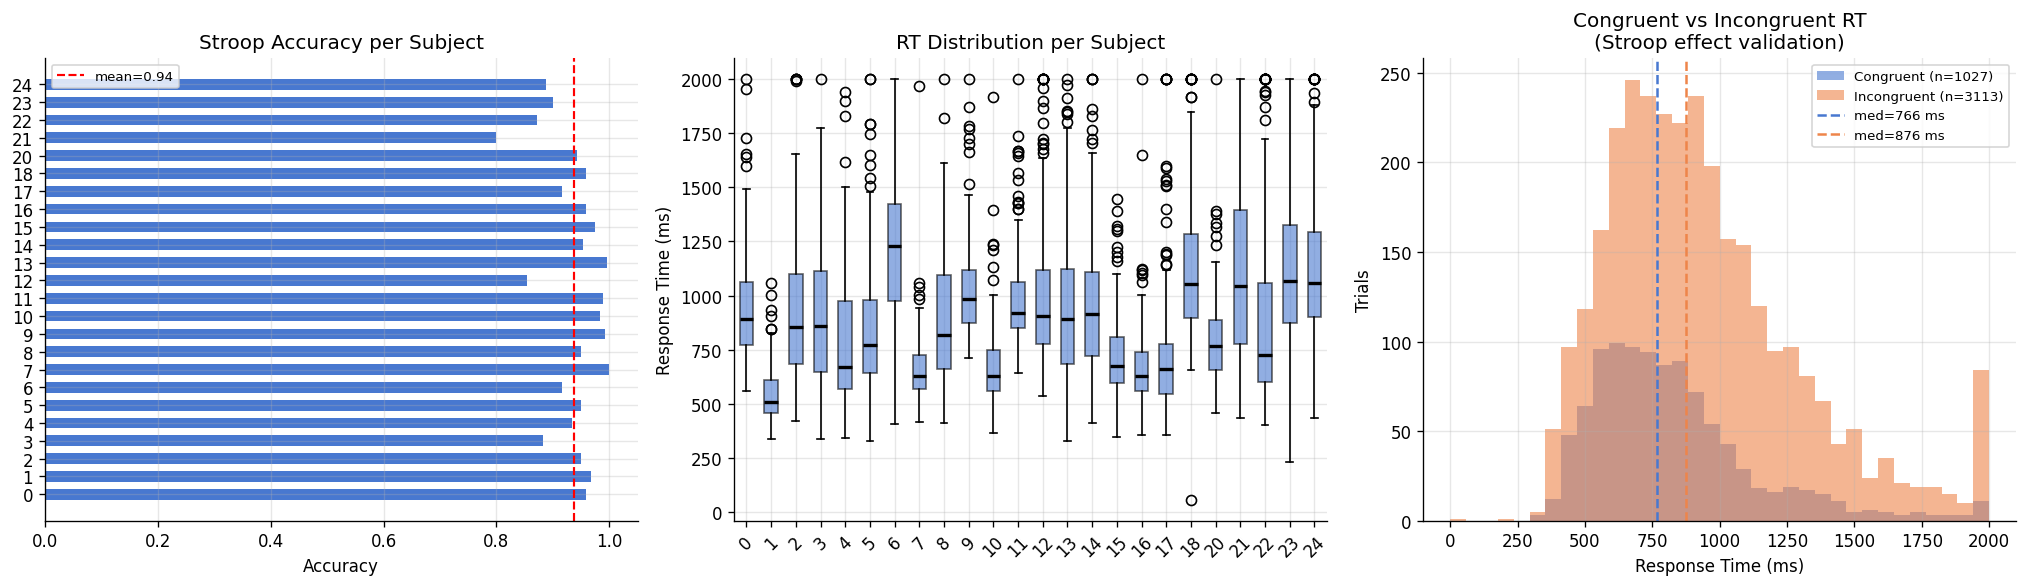

In [73]:
if not stroop_df.empty and "status" in stroop_df.columns and "rt_ms" in stroop_df.columns:
    subjects_st = sorted(stroop_summary.index.tolist())

    fig, axes = plt.subplots(1, 3, figsize=(17, 5))

    # Panel 1: accuracy per subject
    accs = stroop_summary.loc[subjects_st, "accuracy"].values
    axes[0].barh(range(len(subjects_st)), accs, color="#4878D0", height=0.6)
    axes[0].axvline(accs.mean(), color="red", linestyle="--",
                    linewidth=1.3, label=f"mean={accs.mean():.2f}")
    axes[0].set_yticks(range(len(subjects_st)))
    axes[0].set_yticklabels(subjects_st)
    axes[0].set_xlabel("Accuracy")
    axes[0].set_xlim(0, 1.05)
    axes[0].set_title("Stroop Accuracy per Subject")
    axes[0].legend(fontsize=8)

    # Panel 2: RT box plots per subject
    rt_data = [stroop_df[stroop_df["subject"] == s]["rt_ms"].dropna().values for s in subjects_st]
    bp = axes[1].boxplot(rt_data, positions=range(len(subjects_st)), vert=True,
                         widths=0.55, patch_artist=True,
                         boxprops={"facecolor": "#4878D0", "alpha": 0.6},
                         medianprops={"color": "black", "linewidth": 2})
    axes[1].set_xticks(range(len(subjects_st)))
    axes[1].set_xticklabels(subjects_st, rotation=45)
    axes[1].set_ylabel("Response Time (ms)")
    axes[1].set_title("RT Distribution per Subject")

    # Panel 3: congruent vs incongruent RT
    if "congruent" in stroop_df.columns:
        rt_cong   = stroop_df[stroop_df["congruent"] == 1]["rt_ms"].dropna()
        rt_incong = stroop_df[stroop_df["congruent"] == 0]["rt_ms"].dropna()
        q99 = stroop_df["rt_ms"].quantile(0.99)
        bins = np.linspace(0, q99, 35)
        axes[2].hist(rt_cong,   bins=bins, alpha=0.6, color="#4878D0",
                     label=f"Congruent (n={len(rt_cong)})")
        axes[2].hist(rt_incong, bins=bins, alpha=0.6, color="#EE854A",
                     label=f"Incongruent (n={len(rt_incong)})")
        axes[2].axvline(rt_cong.median(),   color="#4878D0", linestyle="--",
                        label=f"med={rt_cong.median():.0f} ms")
        axes[2].axvline(rt_incong.median(), color="#EE854A", linestyle="--",
                        label=f"med={rt_incong.median():.0f} ms")
        axes[2].set_xlabel("Response Time (ms)")
        axes[2].set_ylabel("Trials")
        axes[2].set_title("Congruent vs Incongruent RT\n(Stroop effect validation)")
        axes[2].legend(fontsize=8)
    else:
        axes[2].set_visible(False)

    plt.tight_layout()
    plt.show()


## 8. Cross-Modality Time Alignment

Do all sensors cover the same time window within a condition?
**BVP, EDA, Temp** come from the same Empatica device so should start/stop together.
**EEG** (Muse headband) is a separate BLE device and may start later or stop earlier.

The *overlap window* is `min(all ends) − max(all starts)` — this is the usable
multimodal recording duration for feature extraction.


In [74]:
align_rows = []
for _, rec in registry.iterrows():
    path = Path(rec["path"])
    row  = {"subject": rec["subject"], "cohort": rec["cohort"],
            "session": rec["session"], "condition": rec["condition"]}
    starts, ends = {}, {}
    for mod, fname in MODALITY_MAP.items():
        df = safe_read(path, fname)
        if df is not None and "time" in df.columns and len(df) > 1:
            starts[mod] = float(df["time"].min())
            ends[mod]   = float(df["time"].max())
        else:
            starts[mod] = np.nan
            ends[mod]   = np.nan
        row[f"{mod}_start"] = starts[mod]
        row[f"{mod}_end"]   = ends[mod]
        dur = ends[mod] - starts[mod] if not np.isnan(starts[mod]) else np.nan
        row[f"{mod}_dur_s"] = dur

    valid_s = [v for v in starts.values() if not np.isnan(v)]
    valid_e = [v for v in ends.values()   if not np.isnan(v)]
    if valid_s and valid_e:
        row["overlap_s"]      = max(0.0, min(valid_e) - max(valid_s))
        row["start_spread_s"] = max(valid_s) - min(valid_s)
        row["end_spread_s"]   = max(valid_e) - min(valid_e)
    else:
        row["overlap_s"] = row["start_spread_s"] = row["end_spread_s"] = np.nan
    align_rows.append(row)
align_df = pd.DataFrame(align_rows)

print("Cross-modality overlap window (seconds):")
print(align_df["overlap_s"].describe().round(1))
short = align_df[align_df["overlap_s"] < 60].dropna(subset=["overlap_s"])
if not short.empty:
    print(f"\nRecordings with < 60 s overlap: {len(short)}")
    display(short[["subject","cohort","session","condition","overlap_s","start_spread_s"]].round(1))


Cross-modality overlap window (seconds):
count     70.0
mean     221.9
std       66.6
min       32.2
25%      183.2
50%      194.6
75%      273.1
max      429.8
Name: overlap_s, dtype: float64

Recordings with < 60 s overlap: 1


,subject,cohort,session,condition,overlap_s,start_spread_s
24,11,survey,post,cognitive_load,32.2,0.0


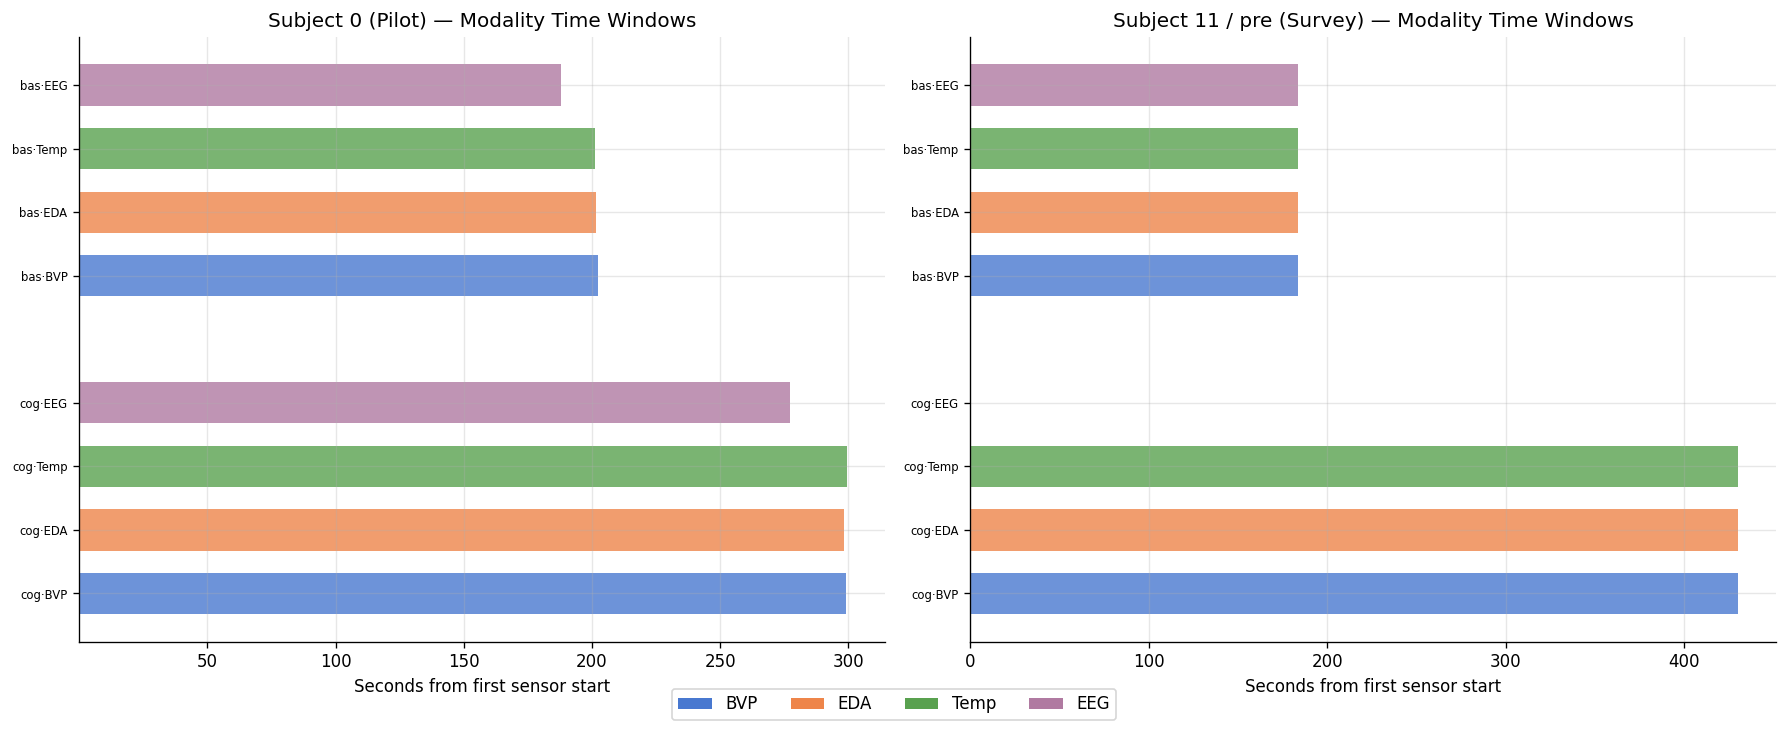

In [75]:
def plot_gantt(ax, align_df, subject_id, session=None, title=""):
    mask = align_df["subject"] == subject_id
    if session is not None:
        mask &= align_df["session"] == session
    sub = align_df[mask].reset_index(drop=True)
    if sub.empty:
        ax.set_title(f"{title}\n(no data)")
        return

    cond_offsets = {"cognitive_load": 0, "baseline": len(MODALITY_MAP) + 1}
    n_rows = (len(MODALITY_MAP) + 1) * 2
    mods   = list(MODALITY_MAP.keys())

    for _, rec in sub.iterrows():
        base_y = cond_offsets.get(rec["condition"], 0)
        t0_vals = [rec[f"{m}_start"] for m in mods if not np.isnan(rec[f"{m}_start"])]
        if not t0_vals:
            continue
        t_ref = min(t0_vals)
        for j, mod in enumerate(mods):
            t_s = rec[f"{mod}_start"]
            t_e = rec[f"{mod}_end"]
            if np.isnan(t_s):
                continue
            ax.barh(base_y + j, t_e - t_s, left=t_s - t_ref,
                    height=0.65, color=MOD_COLORS[mod], alpha=0.8)

    ytick_pos, ytick_lbl = [], []
    for cond, base in sorted(cond_offsets.items()):
        for j, mod in enumerate(mods):
            ytick_pos.append(base + j)
            ytick_lbl.append(f"{cond[:3]}·{mod}")
    ax.set_yticks(ytick_pos)
    ax.set_yticklabels(ytick_lbl, fontsize=7)
    ax.set_xlabel("Seconds from first sensor start")
    ax.set_title(title)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
plot_gantt(axes[0], align_df, subject_id=0,
           title="Subject 0 (Pilot) — Modality Time Windows")
plot_gantt(axes[1], align_df, subject_id=11, session="pre",
           title="Subject 11 / pre (Survey) — Modality Time Windows")

legend_els = [mpatches.Patch(facecolor=c, label=m) for m, c in MOD_COLORS.items()]
fig.legend(handles=legend_els, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.show()


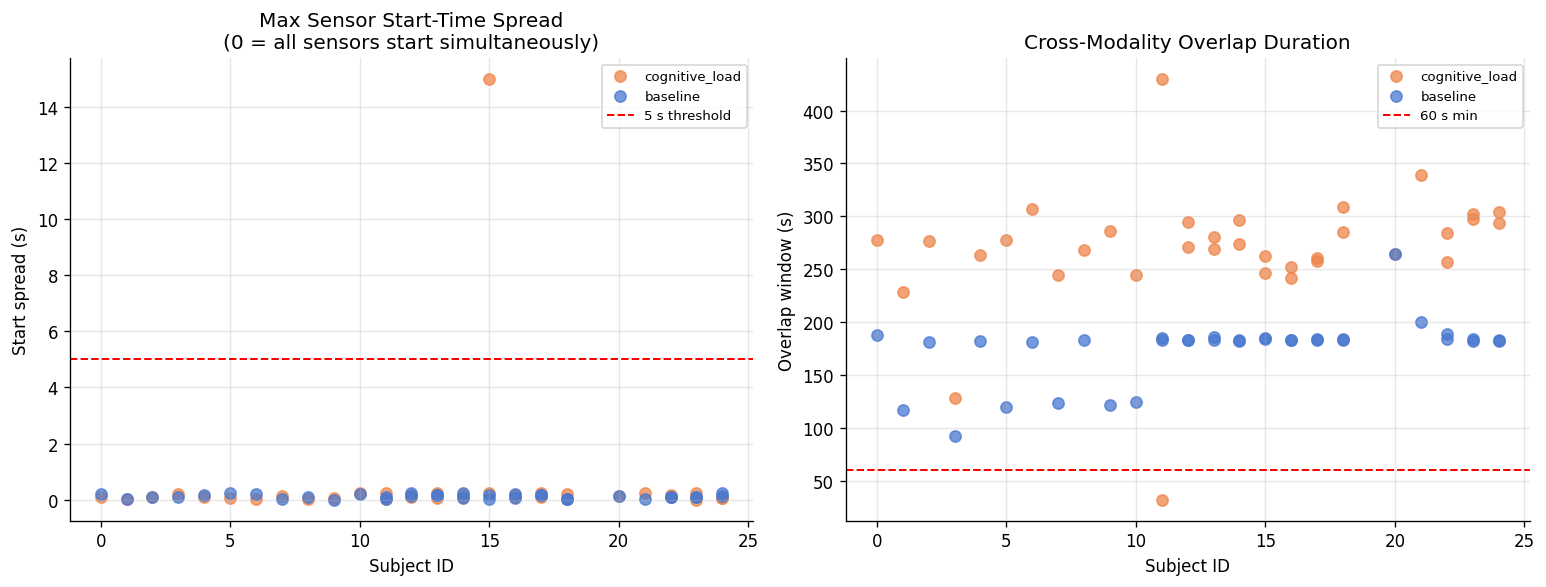

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for cond, clr in COND_COLORS.items():
    sub = align_df[align_df["condition"] == cond]
    axes[0].scatter(sub["subject"], sub["start_spread_s"],
                    color=clr, label=cond, alpha=0.75, s=45)
    axes[1].scatter(sub["subject"], sub["overlap_s"],
                    color=clr, label=cond, alpha=0.75, s=45)

axes[0].axhline(5, color="red", linestyle="--", linewidth=1.2, label="5 s threshold")
axes[0].set_xlabel("Subject ID")
axes[0].set_ylabel("Start spread (s)")
axes[0].set_title("Max Sensor Start-Time Spread\n(0 = all sensors start simultaneously)")
axes[0].legend(fontsize=8)

axes[1].axhline(60, color="red", linestyle="--", linewidth=1.2, label="60 s min")
axes[1].set_xlabel("Subject ID")
axes[1].set_ylabel("Overlap window (s)")
axes[1].set_title("Cross-Modality Overlap Duration")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


## Summary of EDA Findings

### Data Inventory
- **70 condition-recordings** total: 35 cl=0 (baseline) · 35 cl=1 (cognitive_load) — balanced by design
- Subject 19 absent entirely; subjects 20 & 21 have no `post/` session
- **7 missing signal files, all `muse_eeg.csv`:** pilot/3 (both conditions), survey/11/pre/cognitive_load, survey/14/post (both conditions), survey/20/pre/baseline, survey/24/pre/cognitive_load
- BVP, EDA, and Temp are present for every recording

### Recording Lengths
- `cognitive_load` ≈ 280 s (4.7 min); `baseline` ≈ 150 s (2.5 min)
- **Time imbalance:** `cognitive_load` windows contain ~2× more data despite equal recording counts

### Observed Sampling Rates
- BVP: 64 Hz · EDA: 4 Hz · Temp: 4 Hz · EEG: ~256 Hz (deduped)
- EEG file has 2–5 duplicate rows per 1 ms timestamp (Muse SDK windowing) — must deduplicate before use

### Sensor Artifacts
- Temperature flatlines are expected (slow-changing signal at 4 Hz)
- EEG BLE dropouts are frequent but short (<0.1 s); few exceed 2× median interval meaningfully
- Subjects with mean HSI good% < 80 should be flagged for EEG-based features

### Subject Differences
- **EDA shows 10–20× inter-subject range** → per-subject z-score normalisation is mandatory before training
- Temperature range is tight within subjects but offset between individuals
- BVP amplitude (std) varies moderately; HRV features will need individual-level baselines

### Stroop Label Quality
- Accuracy 88–97% across subjects (appropriate task difficulty)
- Congruency effect confirmed: incongruent RT > congruent RT → valid cognitive manipulation
- Timeout rate < 5% for all subjects → minimal missing trial data

### Time Alignment
- BVP / EDA / Temp start within ~1 s of each other (same Empatica device)
- EEG (Muse) may lag by 0–5 s at start and end 20–30 s early in some recordings
- **Recommended alignment:** clip feature windows to `[max(all starts), min(all ends)]` per condition

---
> ⚠️ **Baseline contamination note:** `baseline` (cl=0) recordings follow the Stroop task.
> The protocol intends 3 minutes of genuine rest, but physiological carry-over (EDA, HRV, EEG)
> in the first ~1–2 minutes is likely. Keep this in mind when interpreting classifier results.
